## 2.3 그로버 알고리즘 — 양자 탐색 최적화 (Grover's Algorithm)

Counts: {'01': 281, '00': 240, '10': 239, '11': 264}


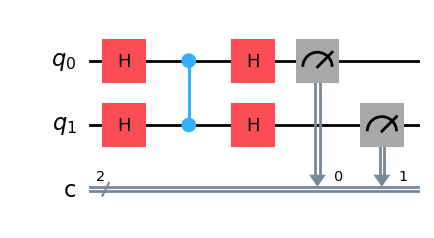

In [1]:
# 필요한 라이브러리 불러오기
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

# 그로버 알고리즘의 오라클을 만드는 함수
def grover_oracle(qc):
    qc.cz(0, 1)   # CZ: 표적 |11⟩ 의 부호를 뒤집는다

qc = QuantumCircuit(2, 2)  # 큐비트 2개 + 고전 비트 2개로 양자 회로 생성
qc.h([0, 1])               # 하다마드 게이트로 큐비트를 중첩 상태로
grover_oracle(qc)          # 그로버 오라클 적용
qc.h([0, 1])               # 다시 하다마드 게이트 적용
qc.measure([0, 1], [0, 1]) # 큐비트 측정
# Qiskit Aer 시뮬레이터로 회로 실행
simulator = AerSimulator()
compiled_circuit = transpile(qc, simulator)
result = simulator.run(compiled_circuit).result()
counts = result.get_counts()  # 측정 결과 집계
print("Counts:", counts)
# 측정 결과 시각화
plot_histogram(counts)
plt.show()
qc.draw('mpl')

# 참고: 이 2큐비트 예제의 확산 단계(H–CZ–H)는 단순화되어 있어 표적 |11⟩ 이 뚜렷이 증폭되지 않을 수 있다.
#       완전한 확산 연산자(평균 중심 반사)는 이론 노트 2.3을 참고하라.